# 3. Long-term behaviour

Over many orbits the *kind* of error matters more than its size after one step. A Runge–Kutta method lets the mass shell $H$ drift linearly; a symplectic method keeps it bounded. Here: 300 radial periods of $(20, 0.5)$ with RK4 and GL2 at the same step (both order 4). Figures F7–F9 run $10^4$ periods with every method.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from geoint.plotting import style

style.apply()
%matplotlib inline

In [2]:
from geoint.experiments import RunSpec, solve
from geoint.experiments.analysis import envelope
from geoint.testcases.schwarzschild import Eccentric

N, steps = 300, 200
case = Eccentric(20.0, 0.5, n_orbits=float(N))
T = case.reference()["T_tau"]
runs = {}
for m in ("RK4", "GL2"):
    sol, form = solve(RunSpec.make(case, "b", m, n_steps=N * steps, save_every=10))
    dH = form.relative_constraint(sol.y, 1)
    runs[m] = envelope(sol.lam, dH, T), sol

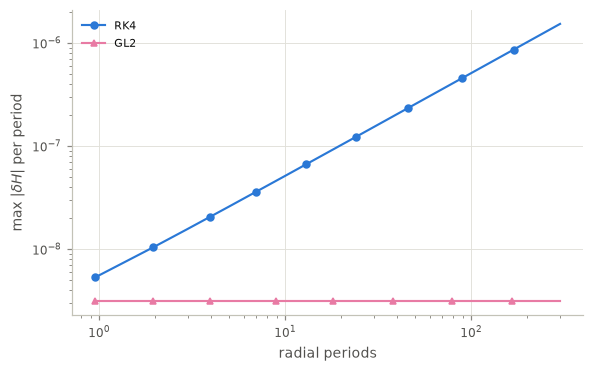

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for m, ((lam, env), _) in runs.items():
    ax.loglog(lam / T, env, **style.method_style(m, markevery=0.1), label=m)
ax.set(xlabel="radial periods", ylabel=r"max $|\delta H|$ per period")
ax.legend();

## Phase error at each periapsis

The exact angle per radial period $\Phi$ is known in closed form, so the phase error at the $N$-th periapsis is $\phi_N - N\Phi$, with no reference integration. RK4's grows like $N^2$, GL2's like $N$.

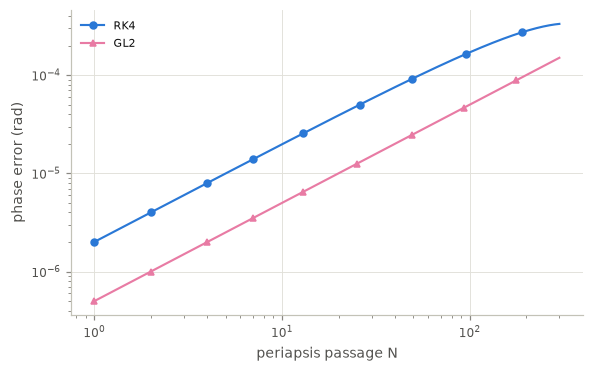

In [4]:
Phi = case.reference()["Phi"]
fig, ax = plt.subplots(figsize=(6, 3.6))
for m, (_, sol) in runs.items():
    peri = sol.events["periapsis"]
    k = np.arange(1, len(peri.lam) + 1)
    ax.loglog(k, np.abs(peri.y[:, 3] - k * Phi), **style.method_style(m, markevery=0.1), label=m)
ax.set(xlabel="periapsis passage N", ylabel="phase error (rad)")
ax.legend();